In [1]:
%run ./start_up.ipynb

Spark version: 3.5.0
Spark UI: http://localhost:4040


In [4]:
from recommenders import train_item_item, get_similar_items_for_user, jaccard_matrix
from pyspark.ml.recommendation import ALSModel

ui_model = ALSModel.load('/home/jovyan/work/models/user-item')
ui_model_better = ALSModel.load('/home/jovyan/work/models/user-item-better')
ui_model_best = ALSModel.load('/home/jovyan/work/models/user-item-better')

trained_ii_model, score_history = train_item_item(anime_data)
trained_ii_model_jacard, score_history_jacard = train_item_item(anime_data, matrix_calc=jaccard_matrix)
target_uid = final_data.select('user_id').first()[0]
def ii_model(user_id, n=10):
    return get_similar_items_for_user(user_id, final_data, trained_ii_model, score_history, n)
def ii_model_jacard(user_id, n=10):
    return get_similar_items_for_user(user_id, final_data, trained_ii_model_jacard, score_history_jacard, n)

In [5]:
# import numpy as np
# from pyspark.sql.functions import row_number
# from pyspark.sql.window import Window

# thresh = 10
# stack  = np.arange(1, 130, 5).tolist()

# user_counts = final_data.groupBy("user_id").count()

# filtered = user_counts.filter(col("count").isin(stack))

# w = Window.partitionBy("count").orderBy("user_id")

# ordered_ids = filtered \
#     .withColumn("rn", row_number().over(w)) \
#     .filter(col("rn") <= thresh) \
#     .drop("rn") \
#     .orderBy("count")

# ordered_ids.show()

import numpy as np
from pyspark.sql.functions import row_number, col, udf
from pyspark.sql.types import IntegerType
from pyspark.sql.window import Window

thresh = 10
stack = np.arange(1, 130, 5).tolist()

# UDF: map any count to nearest stack value
stack_bc = spark.sparkContext.broadcast(stack)

def nearest_stack(count):
    s = stack_bc.value
    return int(min(s, key=lambda x: abs(x - count)))

nearest_udf = udf(nearest_stack, IntegerType())

user_counts = final_data.groupBy("user_id").count()

# Remap every user to their nearest stack value, regardless of threshold
mapped = user_counts \
    .withColumn("mapped_count", nearest_udf(col("count")))

# Cap to thresh users per mapped_count bucket
w = Window.partitionBy("mapped_count").orderBy(col("user_id").asc())

ordered_ids = mapped \
    .withColumn("rn", row_number().over(w)) \
    .filter(col("rn") <= thresh) \
    .drop("rn", "count") \
    .withColumnRenamed("mapped_count", "count") \
    .orderBy(col("count").asc())

ordered_ids.show()

+-------+-----+
|user_id|count|
+-------+-----+
|   7287|    1|
|   7288|    1|
|   7289|    1|
|   7290|    1|
|   7291|    1|
|   7292|    1|
|   7293|    1|
|   7294|    1|
|   7295|    1|
|   7296|    1|
|   2160|    6|
|   2161|    6|
|   2162|    6|
|   2163|    6|
|   2164|    6|
|   2165|    6|
|   2166|    6|
|   2167|    6|
|   2168|    6|
|   2169|    6|
+-------+-----+
only showing top 20 rows



In [41]:
from coverage import precision_recall_at_k, diversity_score, novelty_score
from recommenders import hybridV1, calculate_ui_weights_size

results = {}
idx = {}
k = 10
thresh = 10
for row in ordered_ids.collect():
    user_id = row["user_id"]
    count   = row["count"]
    # if count < 81: # skip already done tests
    #     continue
    if count in idx:
        if idx[count] > thresh:
            continue
        idx[count] += 1
    else:
        idx[count] = 1

    # Collaborative
    target_user = spark.createDataFrame([(user_id,)], ['user_id'])
    als_recs_better = ui_model_better.recommendForUserSubset(target_user, k) \
        .select('user_id', explode('recommendations').alias('rec')) \
        .select(col('rec.anime_id').alias('anime_id')).toPandas()

    als_recs_best = ui_model_best.recommendForUserSubset(target_user, k) \
        .select('user_id', explode('recommendations').alias('rec')) \
        .select(col('rec.anime_id').alias('anime_id')).toPandas()

    ii_recs_cosine = ii_model(user_id, k)
    ii_recs_jacard = ii_model_jacard(user_id, k)
    
    # Hybrid
    dynamic_w = calculate_ui_weights_size(count)
    print(f"User {user_id} | count {count} ")

    hybrid_recs_better_d = hybridV1(
        user_id, ui_model_better, ii_model, final_data, score_history, spark,
        n=10, ui_weight=dynamic_w, ii_weight=(1 - dynamic_w)
    )

    hybrid_recs_best_d = hybridV1(
        user_id, ui_model_best, ii_model, final_data, score_history, spark,
        n=10, ui_weight=dynamic_w, ii_weight=(1 - dynamic_w)
    )

    hybrid_recs_jac_best= hybridV1(
        user_id, ui_model_best, ii_model_jacard, final_data, score_history_jacard, spark,
        n=10, ui_weight=dynamic_w, ii_weight=(1 - dynamic_w)
    )
    
    hybrid_recs_jacard = hybridV1(
        user_id, ui_model_better, ii_model_jacard, final_data, score_history_jacard, spark,
        n=10, ui_weight=dynamic_w, ii_weight=(1 - dynamic_w)
    )

    dynamic_w = calculate_ui_weights_size(count, scaler=2.0)

    hybrid_recs_better_d_05 = hybridV1(
        user_id, ui_model_better, ii_model, final_data, score_history, spark,
        n=10, ui_weight=dynamic_w, ii_weight=(1 - dynamic_w)
    )
    dynamic_w = calculate_ui_weights_size(count, scaler=0.5)

    hybrid_recs_better_d_2 = hybridV1(
        user_id, ui_model_better, ii_model, final_data, score_history, spark,
        n=10, ui_weight=dynamic_w, ii_weight=(1 - dynamic_w)
    )

    if count not in results:
        results[count] = {}

    for name, recs in [
        ('Collaborative', als_recs_better),
        ('Collaborative (best)', als_recs_best),
        ('Hybrid (best)', hybrid_recs_best_d),
        ('Hybrid (jac + best)', hybrid_recs_jac_best),
        ('Hybrid', hybrid_recs_better_d),
        ('Content (cosine)', ii_recs_cosine),
        ('Content (jacard)', ii_recs_jacard),
        ('Hybrid (jacard)', hybrid_recs_jacard),
        ('Hybrid sc0.5', hybrid_recs_better_d_05),
        ('Hybrid sc2', hybrid_recs_better_d_2)
    ]:
        if recs is None:
            continue
        pr  = precision_recall_at_k(user_id, recs, final_data, k=k)
        div = diversity_score(recs, anime_data)
        nov = novelty_score(recs, final_data)

        if not name in results[count]:
            results[count][name] = {
            'precision@k': [],
            'diversity': [],
            'novelty': [],
        }
        results[count][name]['precision@k'].append(pr['precision@k'])
        results[count][name]['diversity'].append(div)
        results[count][name]['novelty'].append(nov)

import json

with open('/home/jovyan/work/output/results_raw.json', 'w') as f:
    json.dump(results, f, indent=2)

User 7287 | count 1 
User 7288 | count 1 
User 7289 | count 1 
User 7290 | count 1 
User 7291 | count 1 
User 7292 | count 1 
User 7293 | count 1 
User 7294 | count 1 
User 7295 | count 1 
User 7296 | count 1 
User 2160 | count 6 
User 2161 | count 6 
User 2162 | count 6 
User 2163 | count 6 
User 2164 | count 6 
User 2165 | count 6 
User 2166 | count 6 
User 2167 | count 6 
User 2168 | count 6 
User 2169 | count 6 
User 1129 | count 11 
User 1130 | count 11 
User 1131 | count 11 
User 1132 | count 11 
User 1133 | count 11 
User 1134 | count 11 
User 1135 | count 11 
User 1136 | count 11 
User 1137 | count 11 
User 1138 | count 11 
User 707 | count 16 
User 708 | count 16 
User 709 | count 16 
User 710 | count 16 
User 711 | count 16 
User 712 | count 16 
User 713 | count 16 
User 714 | count 16 
User 715 | count 16 
User 716 | count 16 
User 492 | count 21 
User 493 | count 21 
User 494 | count 21 
User 495 | count 21 
User 496 | count 21 
User 497 | count 21 
User 498 | count 21 
Use

In [42]:
results = {
    count: {
        name: {
            metric: round(float(np.mean(values)), 4)
            for metric, values in metrics.items()
        }
        for name, metrics in systems.items()
    }
    for count, systems in results.items()
}

In [14]:
import json
with open('/home/jovyan/work/output/results_agg_2.json', 'r') as f:
    results_agg = json.load(f)

# Keys come back as strings — convert back to int if needed
results_agg = {int(k): v for k, v in results_agg.items()}
del results_agg[81]
results_aggs =  results_agg | results
results = results_aggs

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import os

output_dir = '/home/jovyan/work/output/plots'
os.makedirs(output_dir, exist_ok=True)

# --- Plot diversity evolution per rating count ---
def plot_metric(results, metric='diversity', filter=None, name=""):
    # Reshape results dict into a DataFrame
    rows = []
    for count, systems in results.items():
        for system_name, metrics in systems.items():
            if not filter or system_name in filter:
                rows.append({
                'count':       count,
                'system':      system_name.replace("jacard", "jaccard"),
                metric:        metrics[metric]
            })

    df = pd.DataFrame(rows).sort_values('count')

    fig, ax = plt.subplots(figsize=(10, 5))

    for system_name, group in df.groupby('system'):
        ax.plot(
            group['count'],
            group[metric],
            marker='o',
            label=system_name,
            linewidth=2
        )

    ax.set_xlabel('Number of ratings', fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_title(f'{metric.capitalize()} vs Number of Ratings', fontsize=14)
    ax.set_xticks(df['count'].unique())
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/{metric}_evolution_{name}.pdf', format='pdf', bbox_inches='tight')
    plt.show()



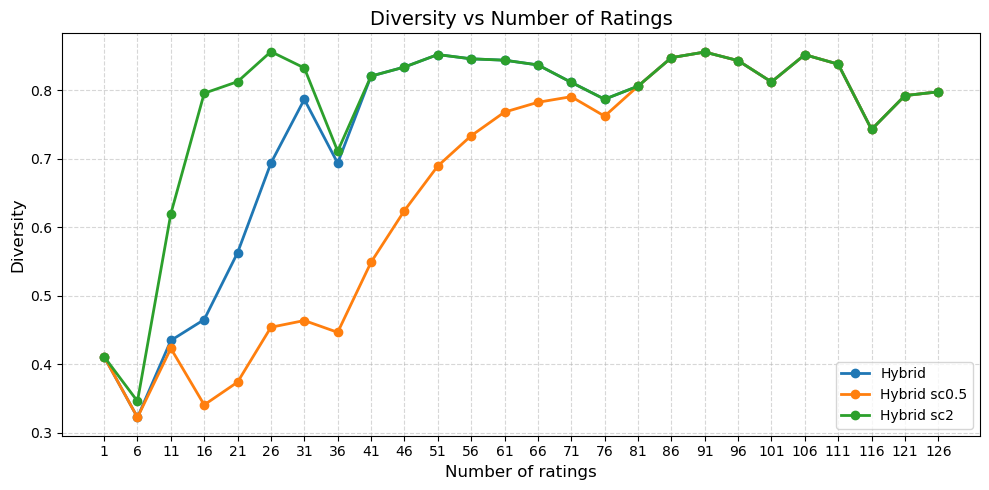

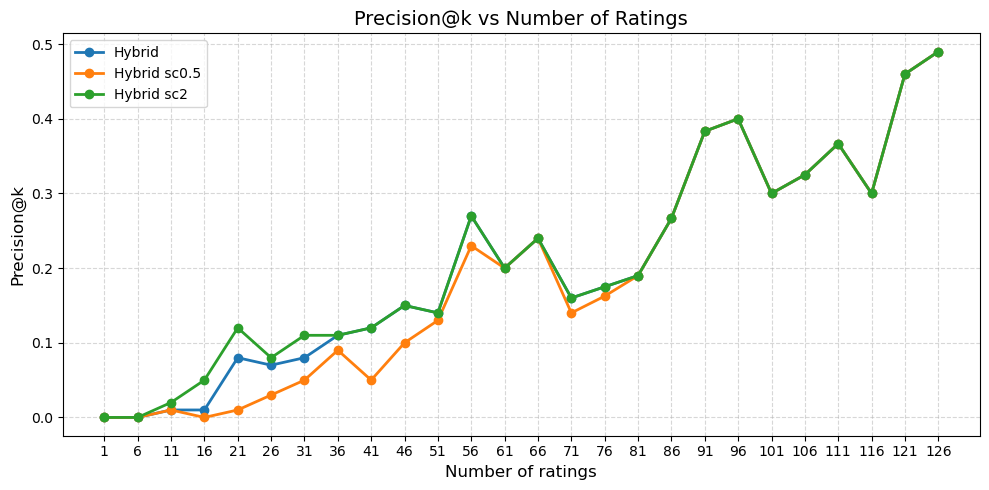

In [65]:
filter = [ 'Hybrid', 'Hybrid sc0.5', 'Hybrid sc2']
plot_metric(results, metric='diversity', filter=filter, name="all_together")
# plot_metric(results, metric='novelty',filter=filter, name="all_together")
plot_metric(results, metric='precision@k',filter=filter, name="all_together")

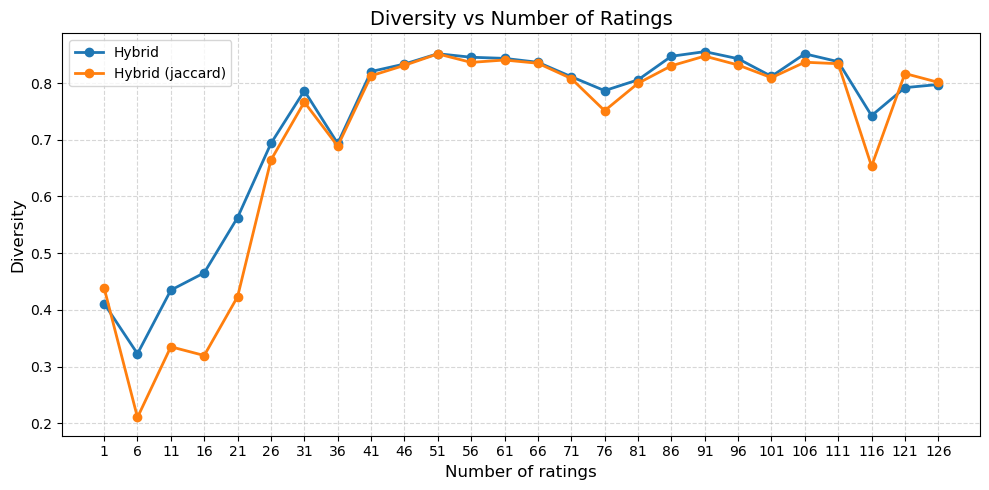

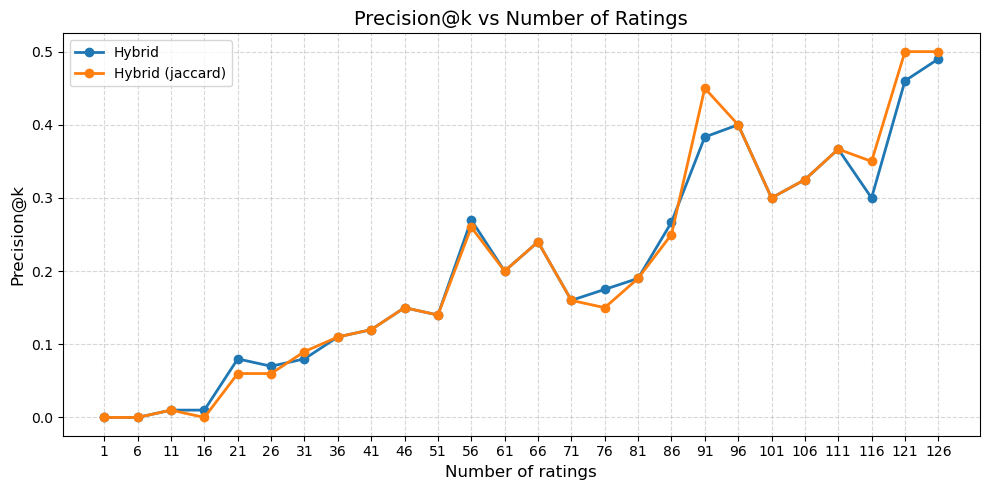

In [66]:
filter = ['Hybrid', 'Hybrid (jacard)']
plot_metric(results, metric='diversity',filter=filter, name="H_cosVjac")
# plot_metric(results, metric='novelty',filter=filter, name="H_cosVjac")
plot_metric(results, metric='precision@k',filter=filter, name="H_cosVjac")

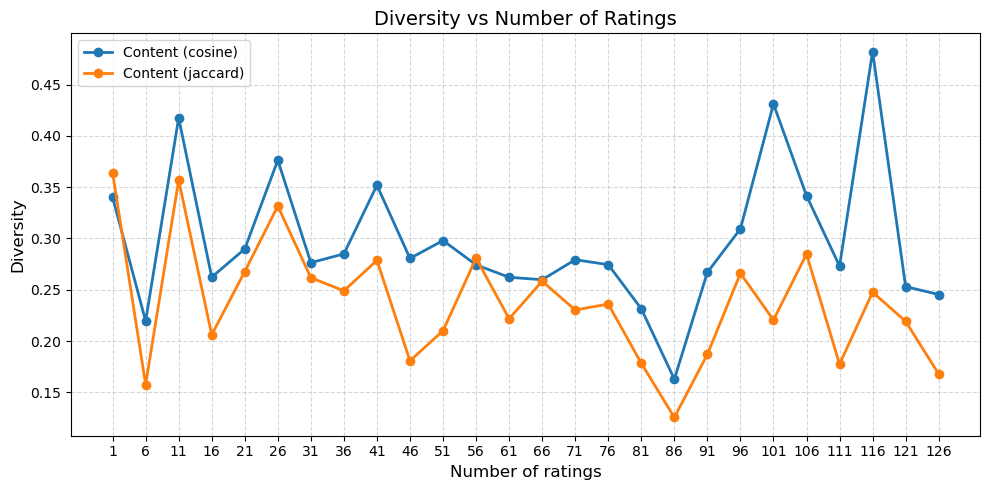

In [67]:
filter = ['Content (cosine)', 'Content (jacard)']
plot_metric(results, metric='diversity',filter=filter, name="Cont_cosVjac")
# plot_metric(results, metric='novelty',filter=filter, name="Cont_cosVjac")
# plot_metric(results, metric='precision@k',filter=filter, name="Cont_cosVjac")

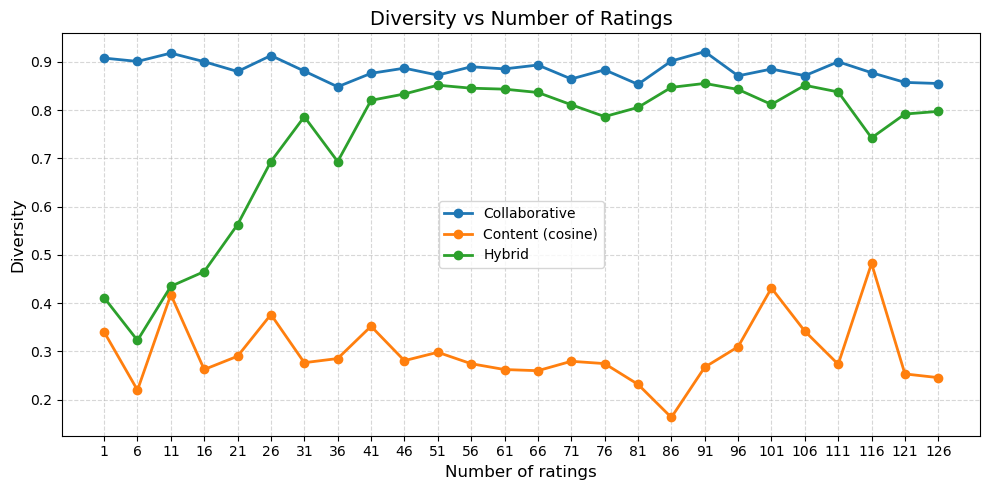

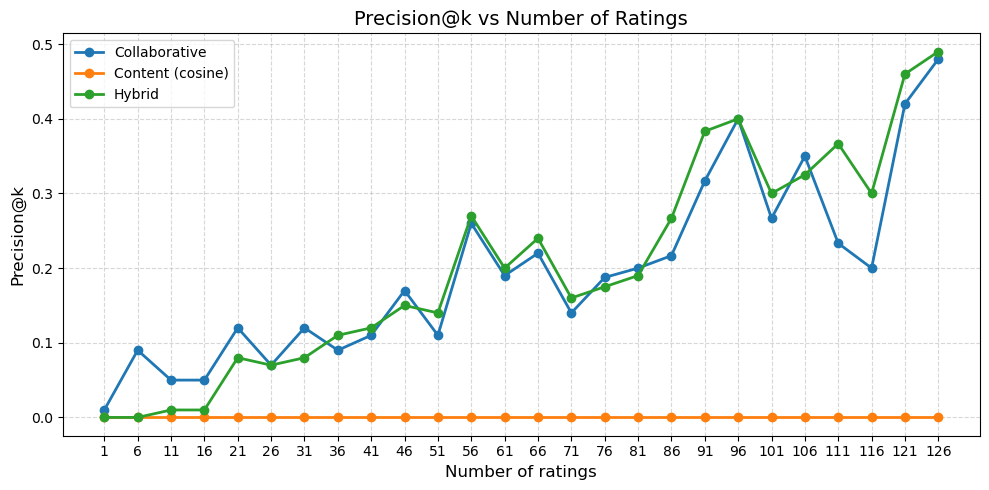

In [68]:
filter = ['Hybrid','Collaborative', 'Content (cosine)']

plot_metric(results, metric='diversity',filter=filter, name="ConHCol")
# plot_metric(results, metric='novelty',filter=filter, name="ConHCol")
plot_metric(results, metric='precision@k',filter=filter, name="ConHCol")

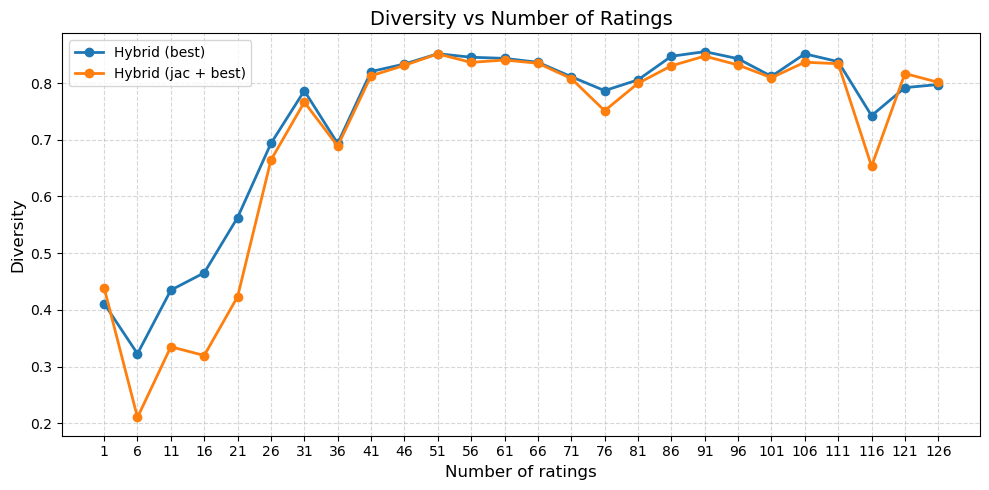

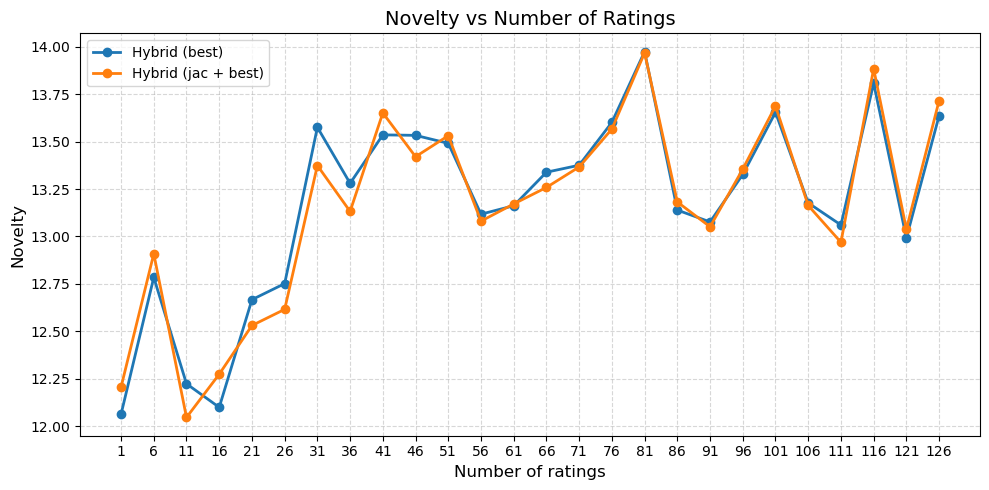

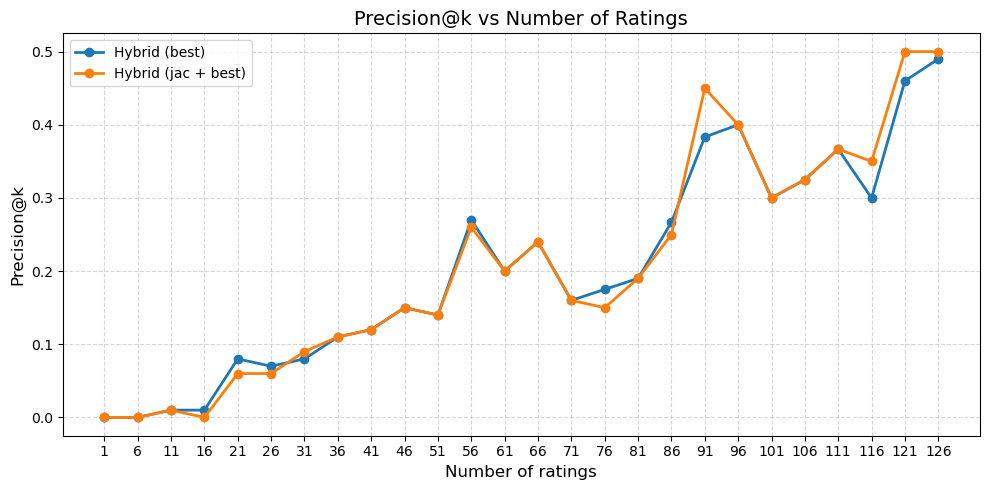

In [49]:
filter = ['Hybrid (best)','Hybrid (jac + best)']

# plot_metric(results, metric='diversity',filter=filter, name="_H_jacVcos")
# plot_metric(results, metric='novelty',filter=filter, name="_Col")
# plot_metric(results, metric='precision@k',filter=filter, name="_Col")

In [16]:
import json

with open('/home/jovyan/work/output/results_agg_2.json', 'w') as f:
    json.dump(results, f, indent=2)